# **Step 1: Load and Inspect the Dataset**

In [ ]:
#1. Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#2. Load the dataset
df = pd.read_csv("/content/train.csv")

In [ ]:
#3. Display the first few rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
#4. Show summary information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
#5. Frequency of feature data types
df.dtypes.value_counts()

,count
object,43
int64,35
float64,3


In [ ]:
#6. Show descriptive analysis
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


# **Step 2: Exploratory Data Analysis**

## A. Univariate Analysis

In [ ]:
#1. Investigate information about the output variable only
df['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [ ]:
#2. Calculate the Skewness and Kurtosis of output variable
print(f"Skewness: {df['SalePrice'].skew()}")
print(f"Kurtosis: {df['SalePrice'].kurt()}")

Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


The value: 1.88 → Positively skewed (long tail on the right)
Interpretation: Most houses are moderately priced, but some are very expensive, pulling the mean upward.

The value: 6.53 → Leptokurtic (more outliers than normal)
Interpretation: There are extreme house prices (both high and low), which could impact regression models.

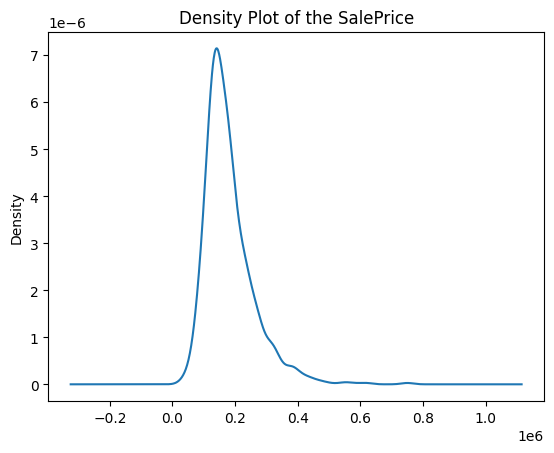

In [ ]:
#3. KDE plot for SalePrice
df['SalePrice'].plot(kind='kde')
plt.title(f'Density Plot of the SalePrice')
plt.show()

In [ ]:
#4. Show bar plots for the first 15 categorical columns
#Extracting the categorical columns names only
categorical_columns = df.select_dtypes(include="object").columns
categorical_columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

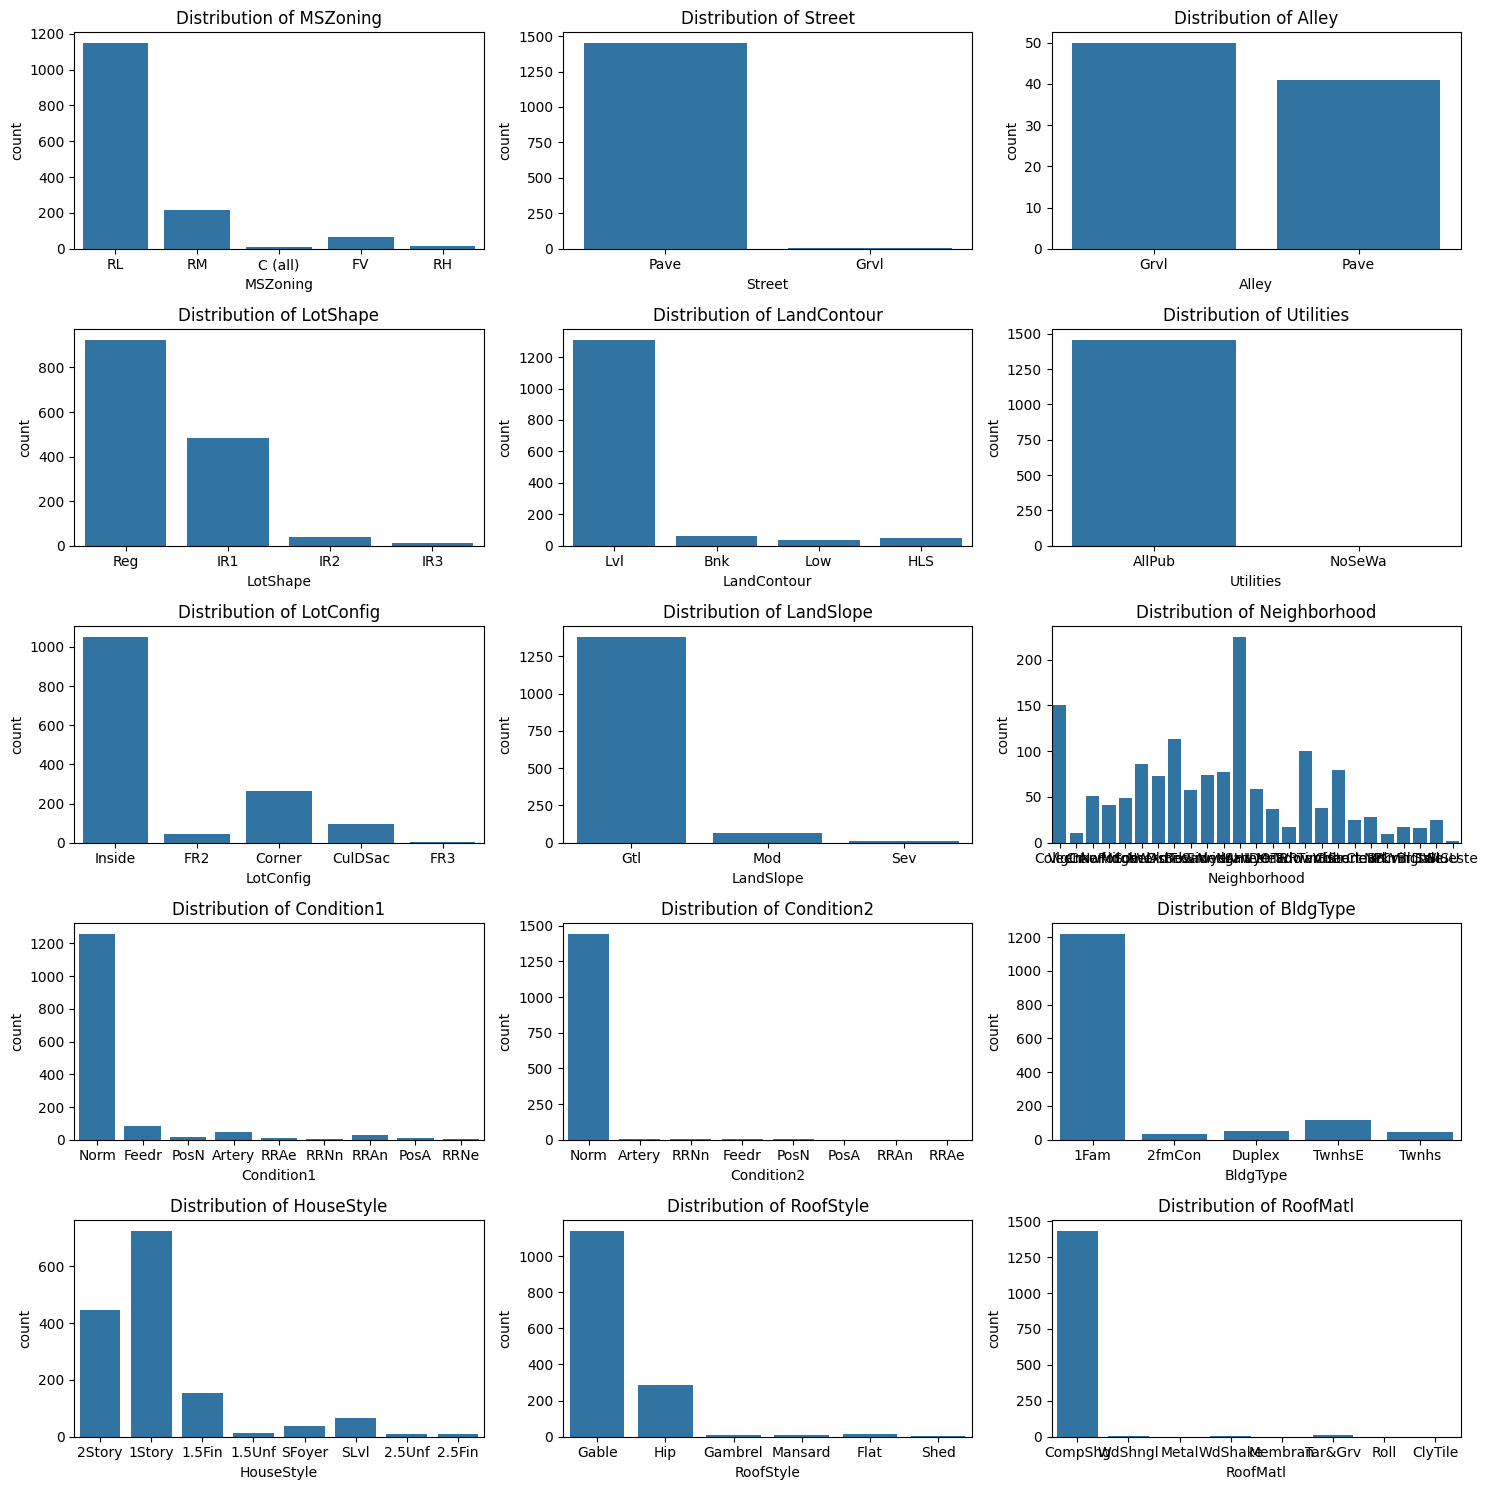

In [ ]:
#Plotting the bar graphs of the first 15 columns only
plt.figure(figsize=(15, 15))

for i, col in enumerate(categorical_columns[:15]):
    plt.subplot(5, 3, i+1)
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

## B. Bivariate Analysis

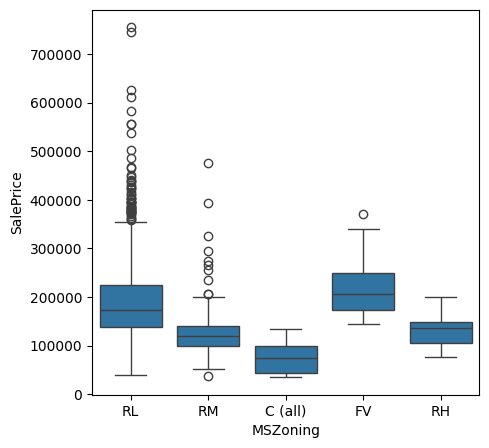

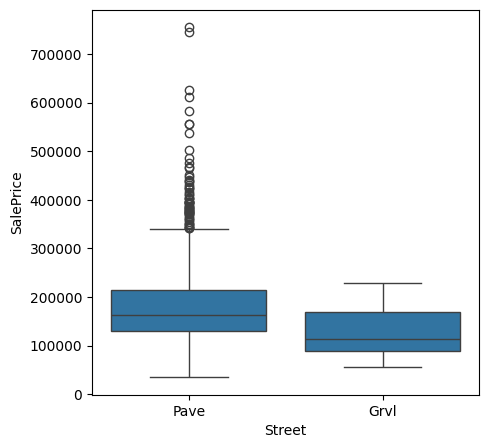

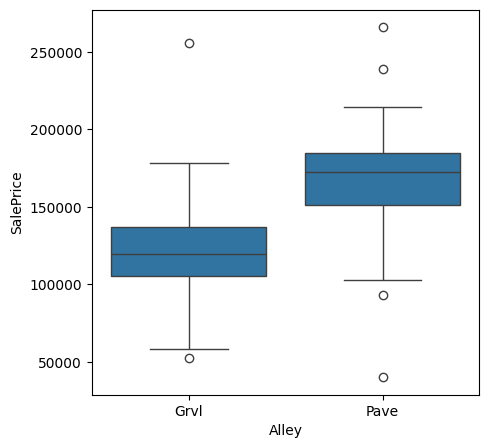

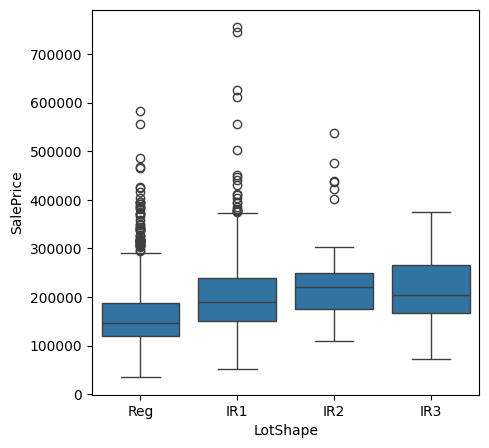

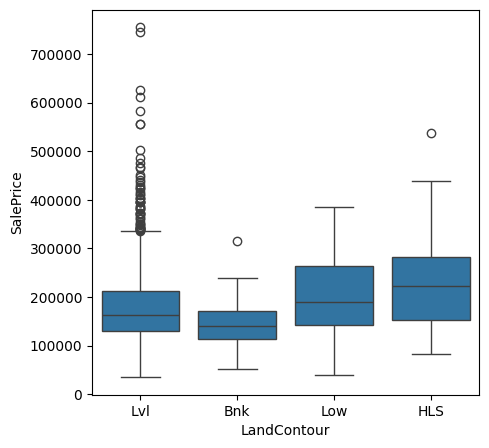

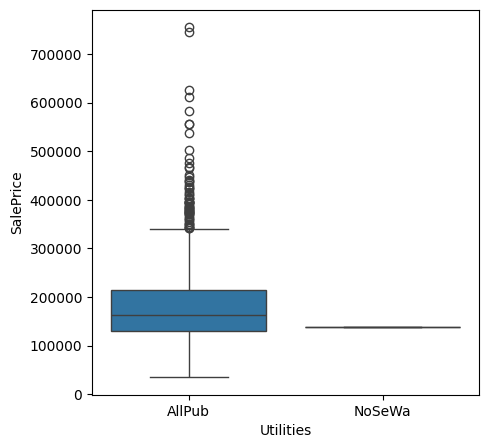

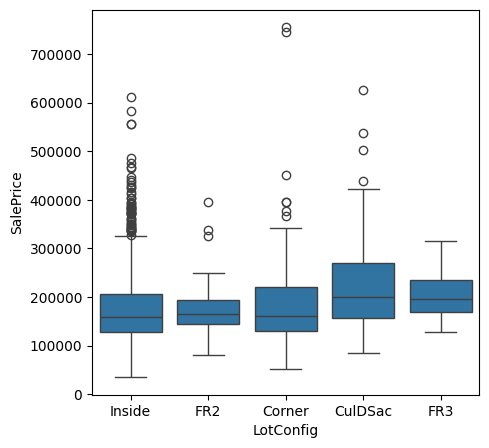

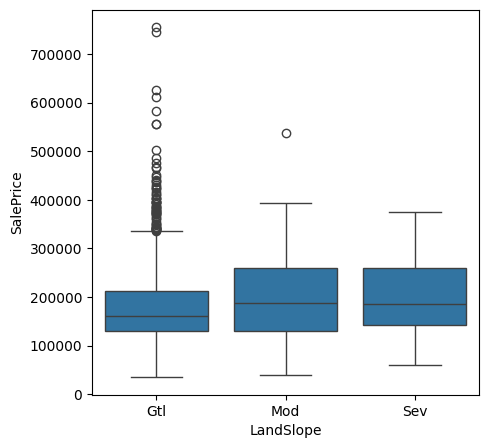

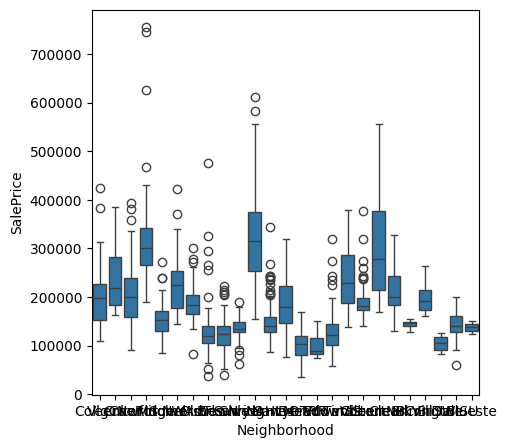

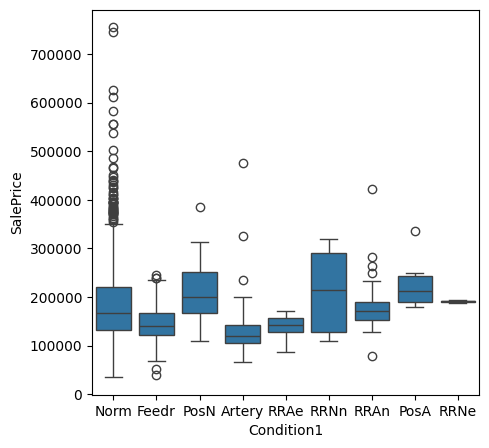

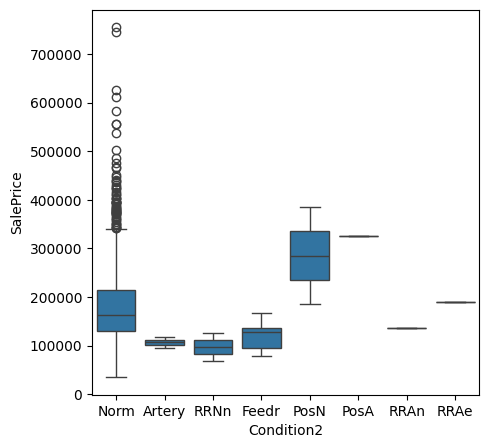

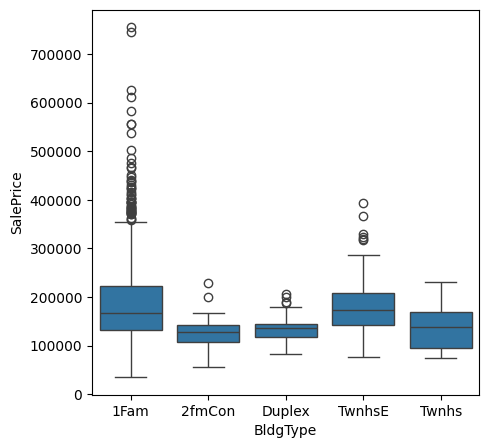

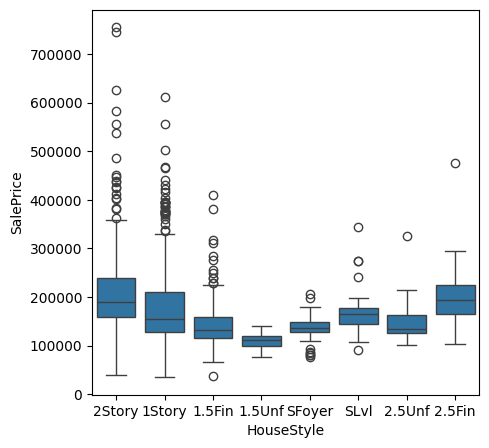

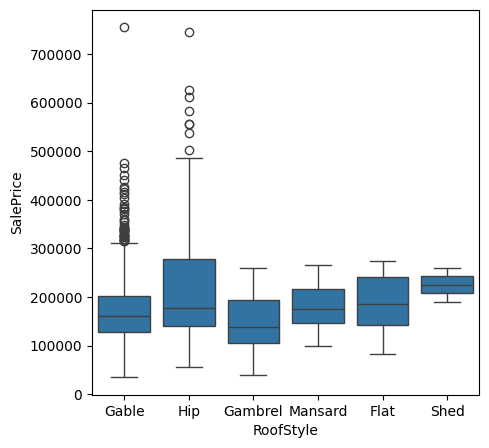

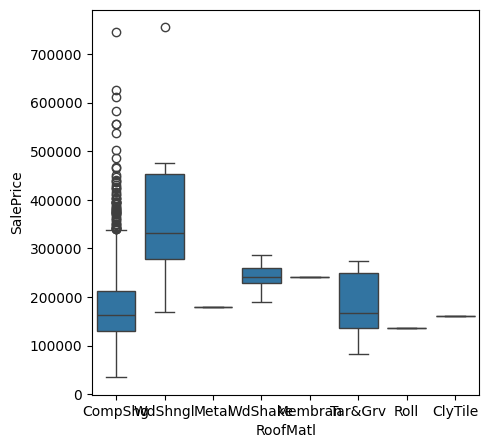

In [ ]:
#1. Show boxplots for the first 15 categorical columns
#   against SalePrice target variable
categorical_columns_list = df.select_dtypes(include="object").columns.tolist()
for cat in categorical_columns_list[:15]:
    plt.figure(figsize=(5, 5))
    sns.boxplot(x=cat, y='SalePrice', data=df)
    plt.show()

## C. Correlation Analysis

In [ ]:
#1. Extracting the numerical columns only into a new dataframe
numerical_df = df.select_dtypes(include="number")
numerical_df

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,349,0,0,0,0,0,0,2,2010,210000
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,0,60,0,0,0,0,2500,5,2010,266500
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,366,0,112,0,0,0,0,4,2010,142125


In [ ]:
#2. Generate correlation values across the numerical columns
corr = numerical_df.corr()
corr.style.background_gradient()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,-0.005968,-0.007940,-0.015415,0.010496,0.005590,-0.044230,0.008273,0.002289,-0.020155,0.005587,0.006784,0.037719,0.002951,0.027239,-0.019772,0.000072,0.016570,0.017634,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,-0.140759,-0.238518,-0.251758,0.307886,0.046474,0.074853,0.003491,-0.002333,0.131608,0.177354,-0.023438,0.281721,0.040380,-0.045569,0.085072,-0.040110,-0.098672,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,0.132644,0.392075,0.457181,0.080177,0.038469,0.402797,0.100949,-0.007234,0.198769,0.053532,0.263170,-0.006069,0.352096,0.266639,0.070250,0.285691,0.344997,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,-0.002618,0.260833,0.299475,0.050986,0.004779,0.263116,0.158155,0.048046,0.126031,0.014259,0.119690,-0.017784,0.190015,0.271364,-0.024947,0.154871,0.180403,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,0.308159,0.537808,0.476224,0.295493,-0.030429,0.593007,0.111098,-0.040150,0.550600,0.273458,0.101676,-0.183882,0.427452,0.396765,0.547766,0.600671,0.562022,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,-0.136841,-0.171098,-0.144203,0.028942,0.025494,-0.079686,-0.054942,0.117821,-0.194149,-0.060769,0.012980,-0.087001,-0.057583,-0.023820,-0.324297,-0.185758,-0.151521,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,0.149040,0.391452,0.281986,0.010308,-0.183784,0.199010,0.187599,-0.038162,0.468271,0.242656,-0.070651,-0.174800,0.095589,0.147716,0.825667,0.537850,0.478954,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,0.181133,0.291066,0.240379,0.140024,-0.062419,0.287389,0.119470,-0.012337,0.439046,0.183331,-0.040581,-0.149598,0.191740,0.112581,0.642277,0.420622,0.371600,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,0.114442,0.363936,0.344501,0.174561,-0.069071,0.390857,0.085310,0.026673,0.276833,0.201444,0.102821,-0.037610,0.280682,0.249070,0.252691,0.364204,0.373066,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,-0.495251,0.522396,0.445863,-0.137079,-0.064503,0.208171,0.649212,0.067418,0.058543,0.004262,-0.107355,-0.081007,0.044316,0.260011,0.153484,0.224054,0.296970,0.204306,0.111761,-0.102303,0.026451

In [ ]:
# 3. Show the strongest 10 positively-correlated features with the SalePrice target variable.
#    Visualize with scatter plots.
positively_correlated_features = corr['SalePrice'].sort_values(ascending = False).head(11)
positively_correlated_features

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


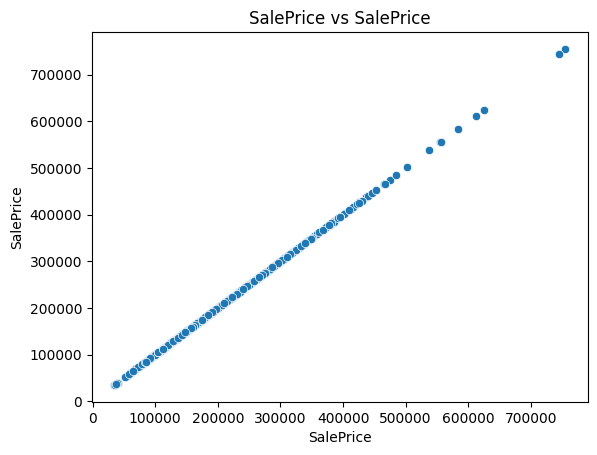

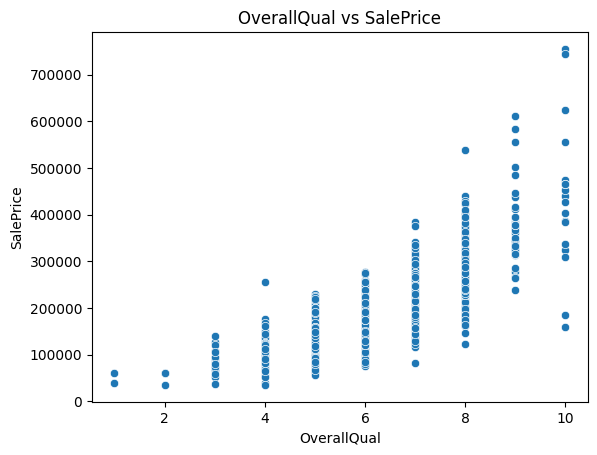

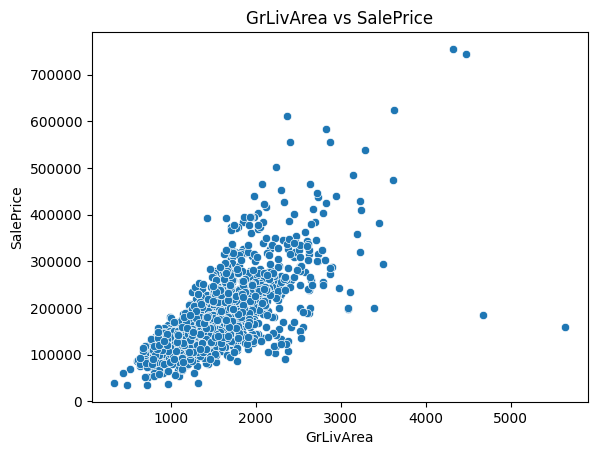

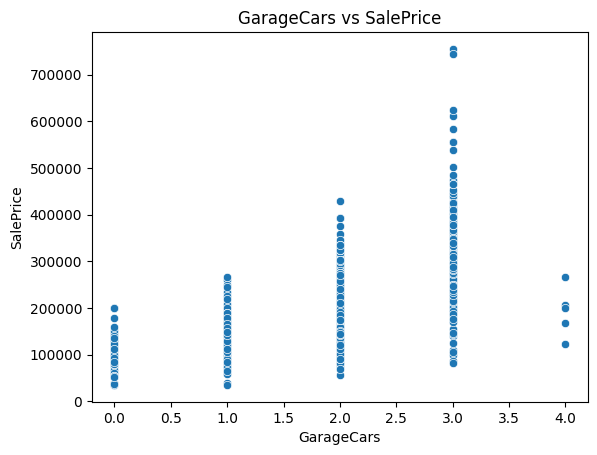

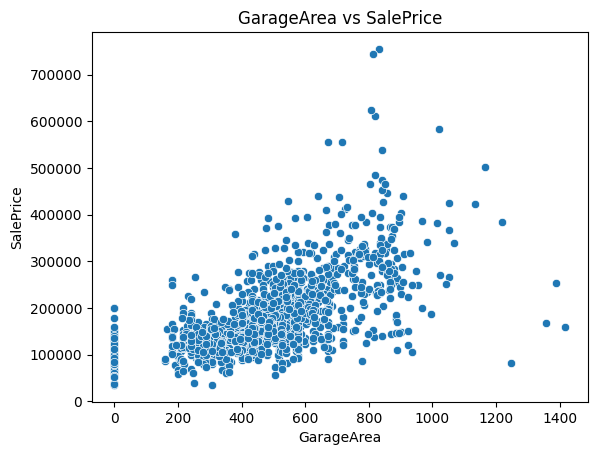

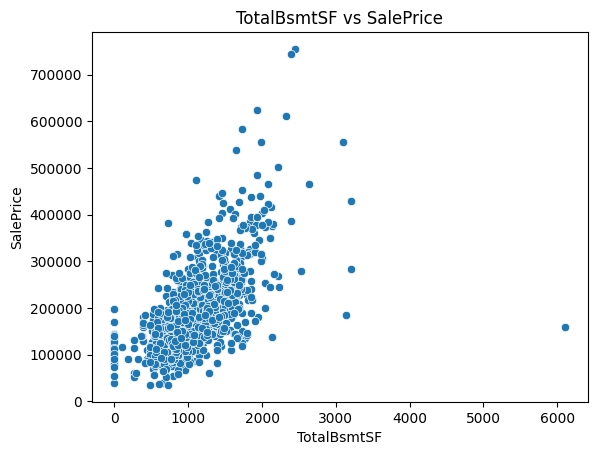

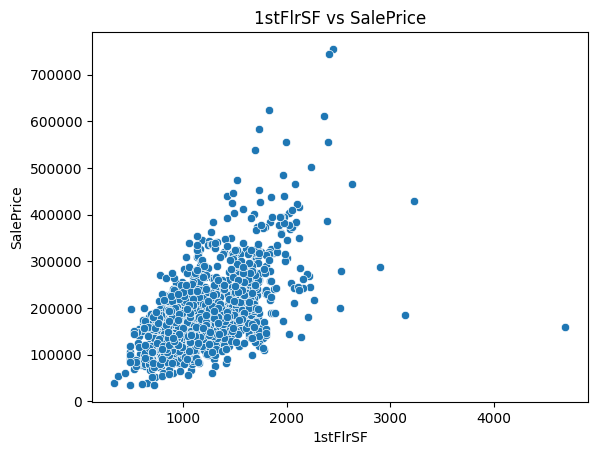

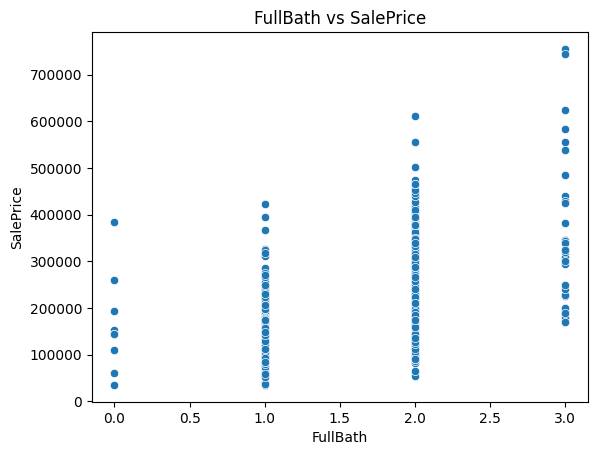

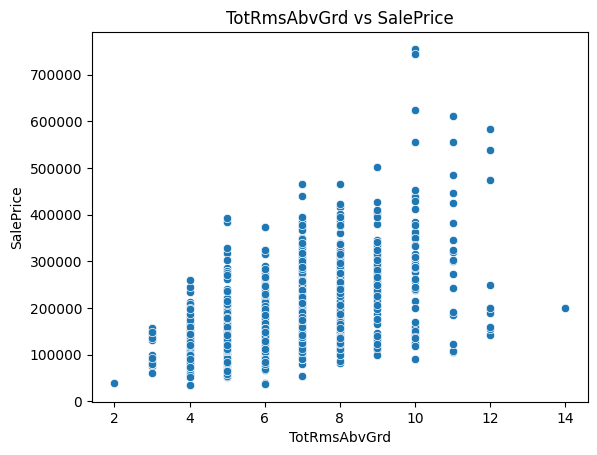

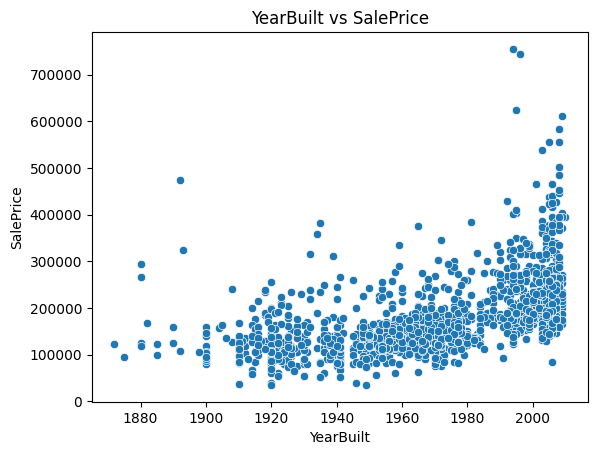

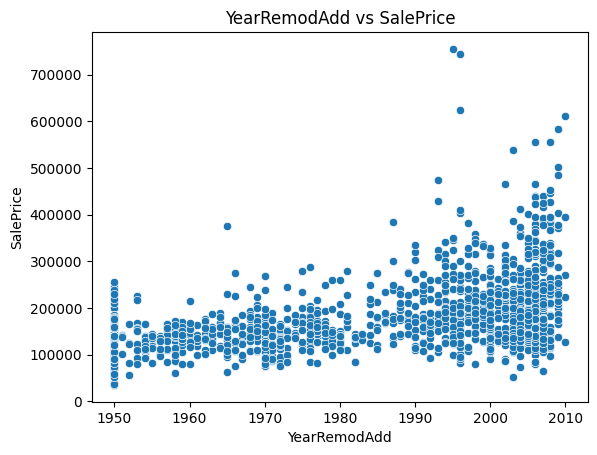

In [ ]:
for index in positively_correlated_features.index:
    fig1, ax = plt.subplots()
    sns.scatterplot(x=index,y='SalePrice', data=df)
    ax.set_title(f"{index} vs SalePrice")
    plt.show()

In [ ]:
#4. Show the strongest 10 negatively-correlated features with the SalePrice target variable.
#   Visualize using scatter plots
negatively_correlated_features = corr['SalePrice'].sort_values(ascending = False).tail(10)
negatively_correlated_features

,SalePrice
BsmtFinSF2,-0.011378
BsmtHalfBath,-0.016844
MiscVal,-0.021190
Id,-0.021917
LowQualFinSF,-0.025606
YrSold,-0.028923
OverallCond,-0.077856
MSSubClass,-0.084284
EnclosedPorch,-0.128578
KitchenAbvGr,-0.135907


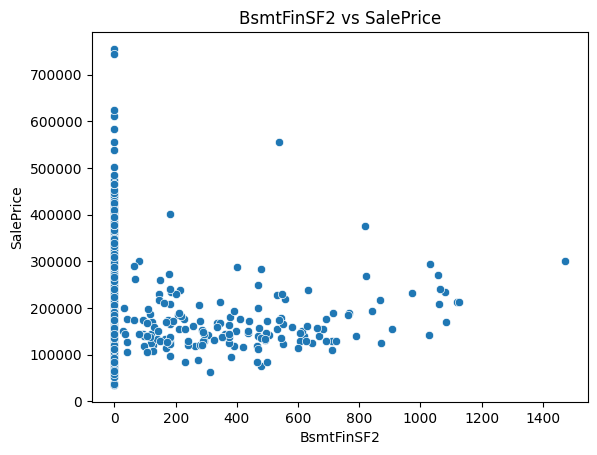

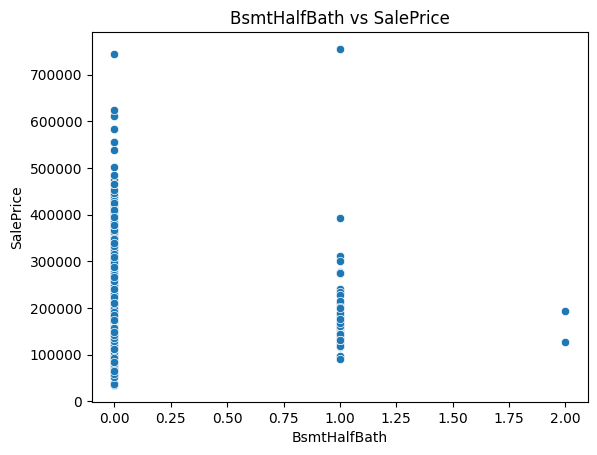

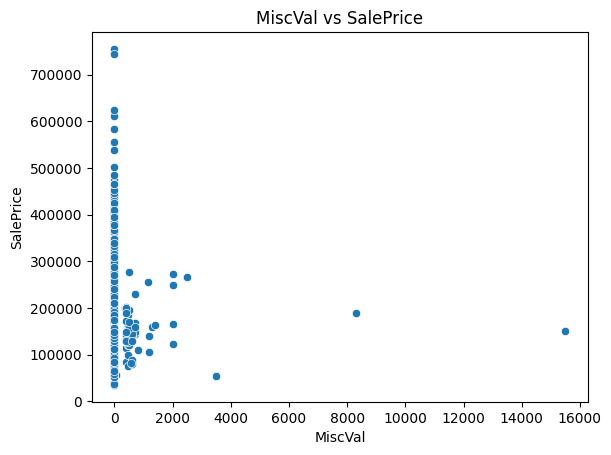

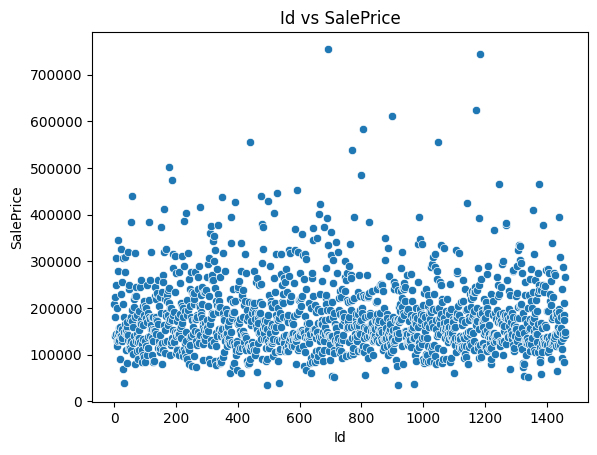

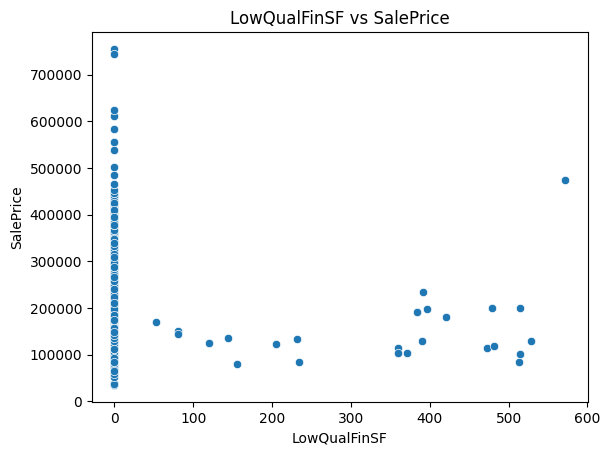

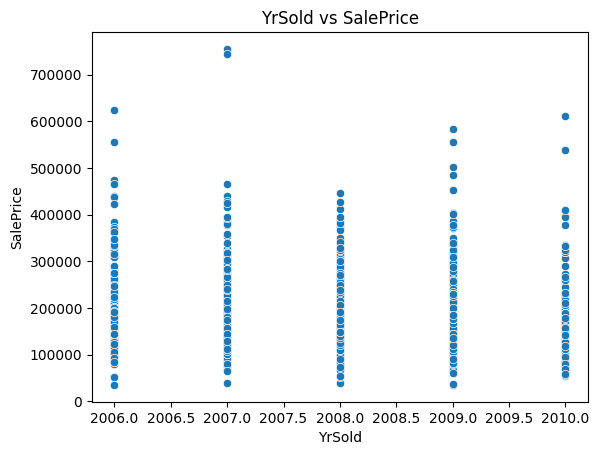

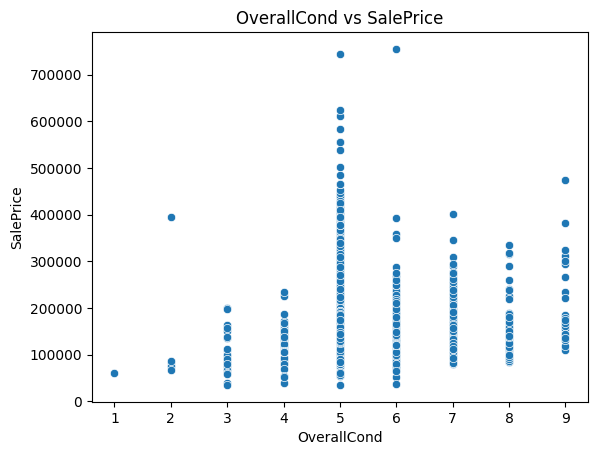

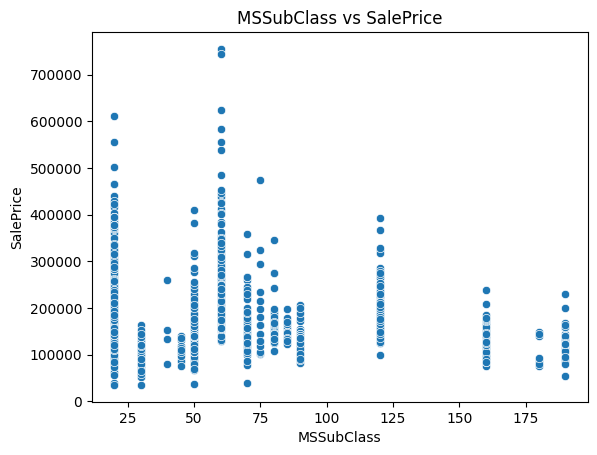

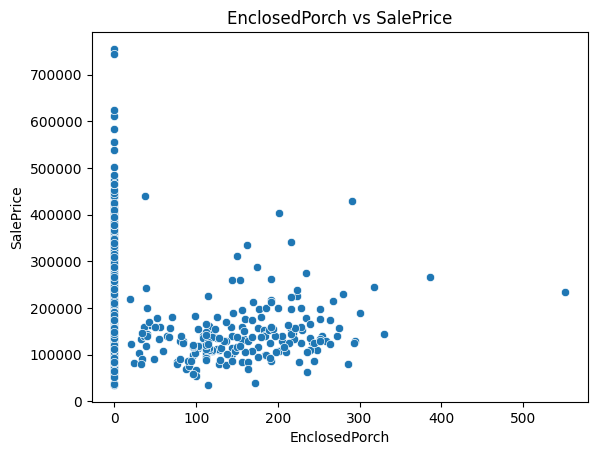

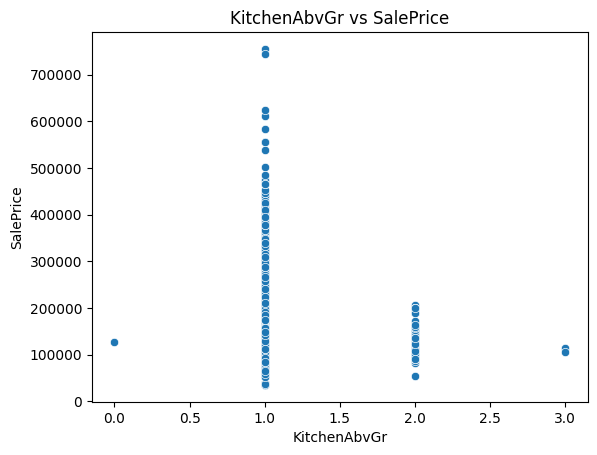

In [ ]:
for index in negatively_correlated_features.index:
    fig1, ax = plt.subplots()
    sns.scatterplot(x=index,y='SalePrice', data=df)
    ax.set_title(f"{index} vs SalePrice")
    plt.show()

## D. Missing Value Analysis

In [ ]:
#1. Get Summary of missing values, ordered descendingly
df.isnull().sum().sort_values(ascending=False).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


## E. Outlier Detection (Using IQR)

In [ ]:
#1. Use IQR to discover outliers in numerical columns
for col in numerical_df.columns.tolist():
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Count of outliers in {col}: {outliers.shape[0]}")

Count of outliers in Id: 0
Count of outliers in MSSubClass: 103
Count of outliers in LotFrontage: 88
Count of outliers in LotArea: 69
Count of outliers in OverallQual: 2
Count of outliers in OverallCond: 125
Count of outliers in YearBuilt: 7
Count of outliers in YearRemodAdd: 0
Count of outliers in MasVnrArea: 96
Count of outliers in BsmtFinSF1: 7
Count of outliers in BsmtFinSF2: 167
Count of outliers in BsmtUnfSF: 29
Count of outliers in TotalBsmtSF: 61
Count of outliers in 1stFlrSF: 20
Count of outliers in 2ndFlrSF: 2
Count of outliers in LowQualFinSF: 26
Count of outliers in GrLivArea: 31
Count of outliers in BsmtFullBath: 1
Count of outliers in BsmtHalfBath: 82
Count of outliers in FullBath: 0
Count of outliers in HalfBath: 0
Count of outliers in BedroomAbvGr: 35
Count of outliers in KitchenAbvGr: 68
Count of outliers in TotRmsAbvGrd: 30
Count of outliers in Fireplaces: 5
Count of outliers in GarageYrBlt: 0
Count of outliers in GarageCars: 5
Count of outliers in GarageArea: 21
Coun

# **Step 3: Data Cleaning**

In [ ]:
#1. Impute missing numerical values
numerical_columns_list = df.select_dtypes(include="number").columns.tolist()
df[numerical_columns_list] = df[numerical_columns_list].fillna(df[numerical_columns_list].median())

#2. Impute missing categorical values
categorical_columns_list = df.select_dtypes(include="object").columns.tolist()
df[categorical_columns_list] = df[categorical_columns_list].fillna(df[categorical_columns_list].mode().iloc[0])

In [ ]:
#3. Remove Numerical outliers
for col in numerical_df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# **Step 4: Data Transformation**

In [ ]:
#1. Recheck the skewness and kurtosis of the target variable after missing value filling, and outlier
#   removal
print(f"Before Transformation Skewness: {df['SalePrice'].skew()}")
print(f"Before Transformation Kurtosis: {df['SalePrice'].kurt()}")

#2. Applying Log transformation to help make it more normal-like
df['SalePrice'] = np.log(df['SalePrice'])

#Calculate the Skewness and Kurtosis of output variable
print(f"After Transformation Skewness: {df['SalePrice'].skew()}")
print(f"After Transformation Kurtosis: {df['SalePrice'].kurt()}")

Before Transformation Skewness: 0.8027863231337099
Before Transformation Kurtosis: 0.08764441519386779
After Transformation Skewness: -0.18514961386141132
After Transformation Kurtosis: 0.3192106930095995


Skew ≈ 0 (normal distribution) → z-score\
High positive/negative skew → min-max


In [ ]:
#3. Normalize numerical features using the appropriate technique
skewness = df[numerical_df.columns].skew()
skewness

,0
Id,0.000000
MSSubClass,1.019624
LotFrontage,0.094443
LotArea,0.208492
OverallQual,0.249513
OverallCond,0.579334
YearBuilt,-0.594020
YearRemodAdd,-0.503562
MasVnrArea,1.287759
BsmtFinSF1,0.739877


In [ ]:
z_score = skewness[(skewness >= -0.5) & (skewness <= 0.5)]
min_max = skewness[(skewness < -0.5) | (skewness > 0.5)]

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()
df_normalized = df.copy()
df_normalized[min_max.index] = scaler.fit_transform(df_normalized[min_max.index])

In [ ]:
scaler = StandardScaler()
df_normalized[z_score.index] = scaler.fit_transform(df_normalized[z_score.index])

In [ ]:
#4. Perform One-Hot encoding on categorical features
categorical_cols = df_normalized.select_dtypes(include=['object']).columns
encoded_df = pd.get_dummies(df_normalized, columns=categorical_cols, drop_first=False)

In [ ]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 289 entries, Id to SaleCondition_Partial
dtypes: bool(251), float64(38)
memory usage: 791.4 KB


In [ ]:
#5. Generate correlation values across the categorical features
bool_df = encoded_df.select_dtypes(include="bool")
bool_df['SalePrice'] = df['SalePrice']
correlation_matrix = bool_df.corr()
correlation_matrix.style.background_gradient()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#6. Show the strongest 10 positively-correlated features with the SalePrice target variable.
positively_correlated_features = correlation_matrix['SalePrice'].sort_values(ascending = False).head(11)
positively_correlated_features

,SalePrice
SalePrice,1.000000
Foundation_PConc,0.536348
ExterQual_Gd,0.532788
HeatingQC_Ex,0.470422
BsmtFinType1_GLQ,0.439684
KitchenQual_Gd,0.435424
BsmtQual_Ex,0.427473
GarageFinish_Fin,0.412905
KitchenQual_Ex,0.374627
BsmtQual_Gd,0.364818


In [ ]:
#7. Show the strongest 10 negatively-correlated features with the SalePrice target variable.
negatively_correlated_features = correlation_matrix['SalePrice'].sort_values(ascending = False).tail(10)
negatively_correlated_features

,SalePrice
BsmtExposure_No,-0.296557
Foundation_CBlock,-0.337519
HeatingQC_TA,-0.339022
MSZoning_RM,-0.358631
CentralAir_N,-0.364129
GarageType_Detchd,-0.396794
KitchenQual_TA,-0.544188
BsmtQual_TA,-0.546915
GarageFinish_Unf,-0.585183
ExterQual_TA,-0.599129
